<a href="https://colab.research.google.com/github/NerusuSahithi011/NLP/blob/main/lab_assigment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
ASSIGNMENT 11

Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model training
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

Load and Preprocess Data

In [14]:
nltk.download('movie_reviews')
nltk.download('stopwords')

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import movie_reviews

documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

df = pd.DataFrame(documents, columns=["review", "sentiment"])

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  plot : two teen couples go to a church party ,...       neg
1  the happy bastard's quick movie review \ndamn ...       neg
2  it is movies like these that make a jaded movi...       neg
3   " quest for camelot " is warner bros . ' firs...       neg
4  synopsis : a mentally unstable man undergoing ...       neg
sentiment
neg    1000
pos    1000
Name: count, dtype: int64


Text Cleaning

In [19]:
import string

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

print(df["clean_review"].head())

0    plot two teen couples go church party drink dr...
1    happy bastards quick movie review damn y2k bug...
2    movies like make jaded movie viewer thankful i...
3    quest camelot warner bros first featurelength ...
4    synopsis mentally unstable man undergoing psyc...
Name: clean_review, dtype: object


Feature Extraction (TF-IDF)

In [20]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment"]

print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 47371


Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Mode

In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Model Evaluation

In [23]:
y_pred = model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="pos")
recall = recall_score(y_test, y_pred, pos_label="pos")
f1 = f1_score(y_test, y_pred, pos_label="pos")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.82
Precision: 0.8208955223880597
Recall: 0.8208955223880597
F1 Score: 0.8208955223880597


Confusion Matrix

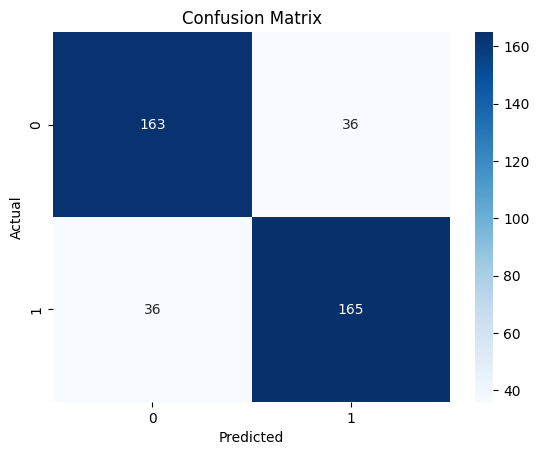

In [25]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.82      0.82      0.82       199
         pos       0.82      0.82      0.82       201

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400

